### Importation : 

In [320]:
import pandas as pd
import warnings
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,make_scorer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

### Read Data :

In [265]:
def read_data(path):
    Data = pd.read_csv(path)
    return Data
Copy_df = read_data("MyRealData.csv")
Data_For_Pipline = read_data("MyRealData.csv")
df = read_data("MyRealData.csv")

### Describe :

In [266]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


### Info :

In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### Missing Values :

In [268]:
def fill_missing_values(data):
    missing_data = data.isnull().sum()
    Columns_missing = missing_data[missing_data > 0].index
    if len(Columns_missing) == 0:
        print("No missing values found.")
        return data
    else:
        for column in Columns_missing:
            if data[column].dtype in ['float64', 'int64']:
                mean_value = data[column].mean()
                data[column].fillna(mean_value, inplace=True)
            else:
                mode_value = data[column].mode()[0]
                data[column].fillna(mode_value, inplace=True)
        return data

df = fill_missing_values(df)
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


### Duplicated Rows :

In [269]:
def Duplicated_Check(Data):
    Duplicate_sum = Data.duplicated().sum()
    if Duplicate_sum == 0:
        print('You dont have any duplicated rows !!')
    else : 
        Data = Data.drop_duplicates()
        return Data
        
Duplicated_Check(df)

You dont have any duplicated rows !!


### remove the Id's Columns :

In [270]:
def remove_id(Data):
    Numeric_Data = Data.select_dtypes(include= ['float64', 'int64'])
    for column in Numeric_Data.columns :
        if Numeric_Data[column].unique().sum() == Numeric_Data[column].sum():
            Data = Data.drop(column, axis=1)
    return Data

remove_id(df)


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


### Distribution de la variable cible :

In [271]:
def auto_normalize(Data):
    Numeric_Data = Data.select_dtypes(include= ['float64', 'int64'])
    for column in Numeric_Data.columns :
        if Numeric_Data[column].unique().sum() != Numeric_Data[column].sum():
            if not (Numeric_Data[column].min() >=0 and Numeric_Data[column].min() <=1) :
                scaled = MinMaxScaler()
                Data[column] = scaled.fit_transform(Data[[column]])
    return Data

### Heatmap de corrélation :

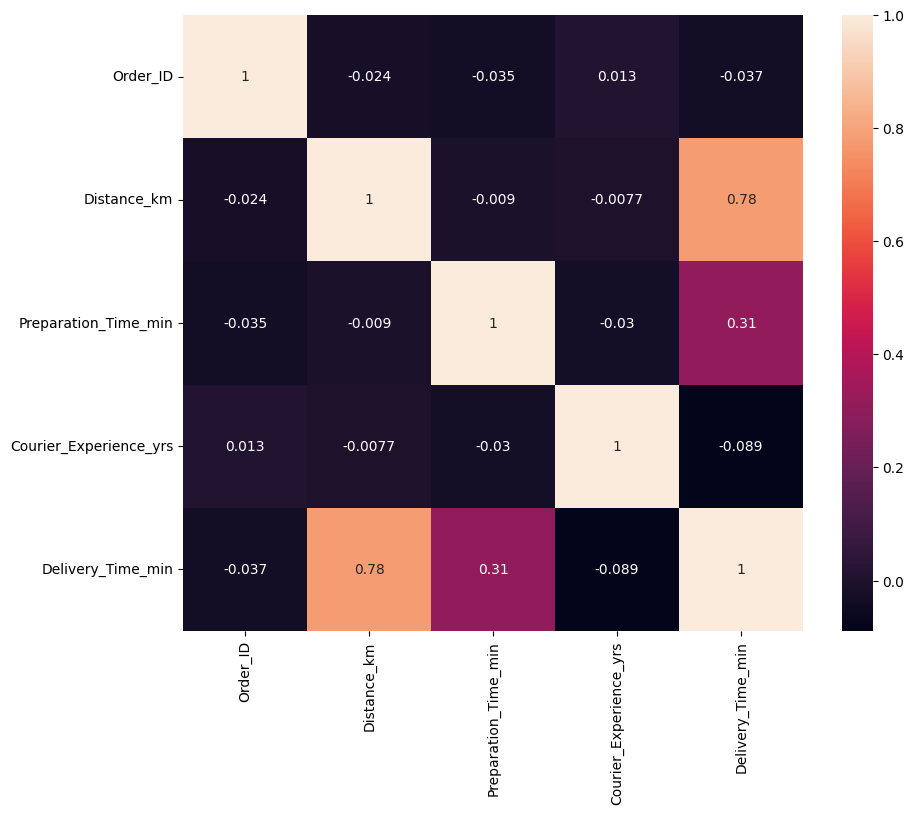

In [272]:
correlation_matrix = df.select_dtypes(include= ['float64', 'int64']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

### countplots for each featuers with target :

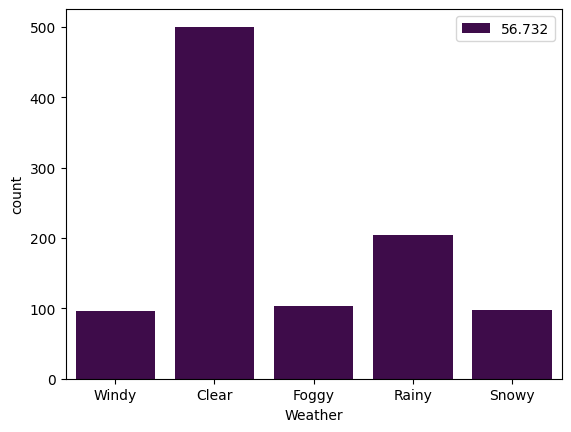

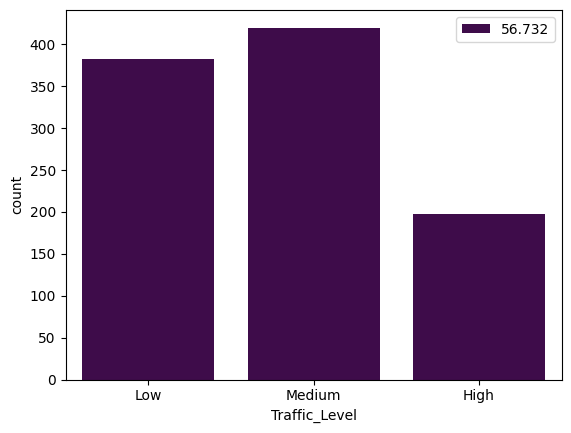

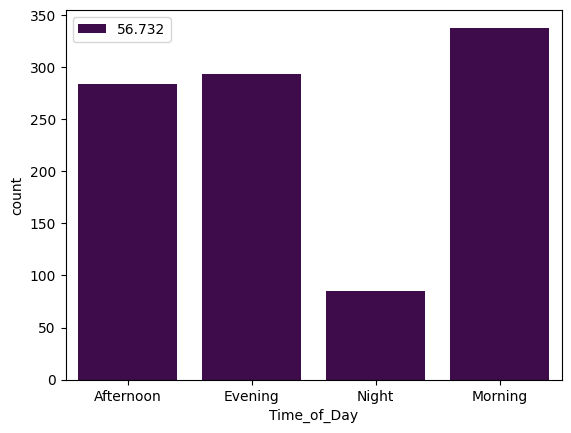

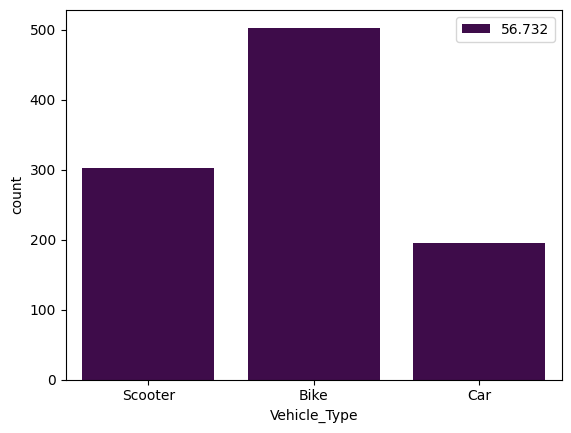

In [273]:
def Split_Object(Data):
    Object_Data = Data.select_dtypes(include=['object'])
    Target = Data['Delivery_Time_min']
    return Object_Data, Target

def Split_Num(Data):
    Object_Data = Data.select_dtypes(include=['int64','float64'])
    Target = Data['Delivery_Time_min']
    return Object_Data, Target

def count_plots(Features,Target): 
    for column in Features.columns:
        sns.countplot(x=column, hue=Target.mean(), data=df, palette='viridis')
        plt.show()

x,y = Split_Object(df) 

count_plots(x,y)

### Boxplots pour analyser la relation entre la cible et les variables catégorielles:

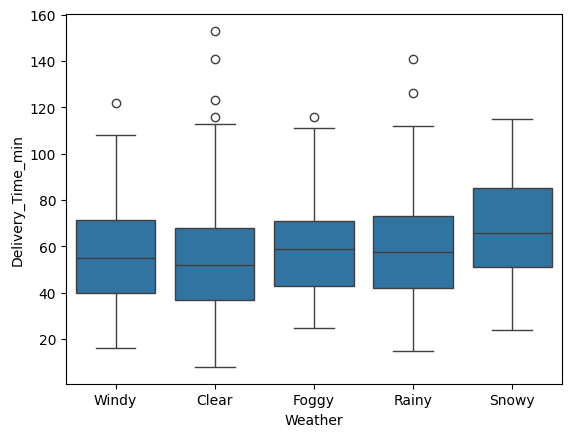

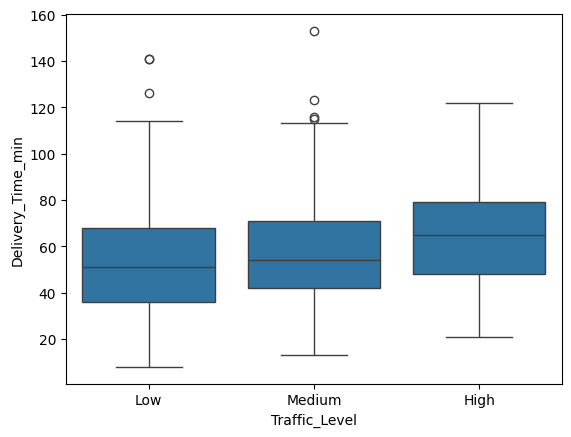

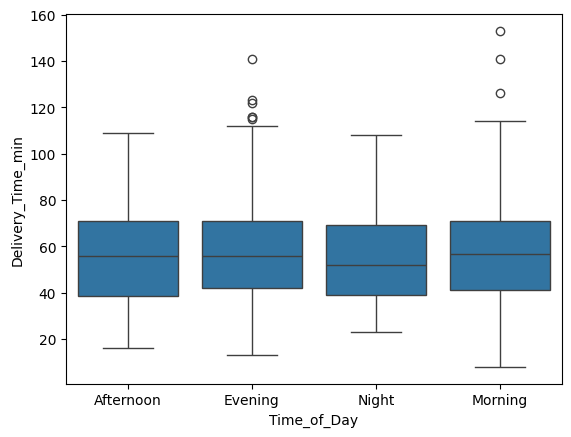

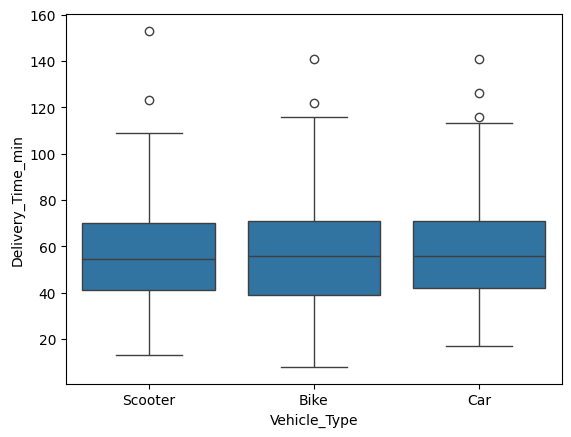

In [274]:
def count_plots(Features,Target): 
    for column in Features.columns:
        sns.boxplot(data=df, x=Features[column], y=Target)
        plt.show()

x,y = Split_Object(df)

count_plots(x,y)

### Encoder Data : 

In [275]:
def encode_Data(Data):
    Object_Data = Data.select_dtypes(include=['object'])
    encoder = LabelEncoder()
    for column in Object_Data.columns:
        Data[column] = encoder.fit_transform(Data[column])
    return Data

df = encode_Data(df)
df


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,1,0,2,12,1.0,43
1,738,16.42,0,2,1,0,20,2.0,84
2,741,9.52,1,1,3,2,28,1.0,59
3,661,7.44,2,2,0,2,5,1.0,37
4,412,19.03,0,1,2,0,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,0,0,1,1,13,3.0,54
996,271,16.28,2,1,2,2,8,9.0,71
997,861,15.62,3,0,1,2,26,2.0,81
998,436,14.17,0,1,0,0,8,0.0,55


### Split Data For Trainanig :

In [345]:
def Split_Data(Data):
    X = Data.drop(columns=['Delivery_Time_min', 'Order_ID','Time_of_Day'], axis=1)
    y = Data['Delivery_Time_min']
    return X, y

def Split_train_test(Data):
    X, y = Split_Data(Data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = Split_train_test(df)


### KSelect :

In [340]:
X, y = Split_Data(df)
X_old = df.drop(columns=['Delivery_Time_min', 'Order_ID','Courier_Experience_yrs'], axis=1)

selector = SelectKBest(score_func=f_regression, k=3)
X_new = selector.fit_transform(X_old, y)

selected_features = pd.DataFrame(
    selector.get_support(),
    index=X_old.columns,
    columns=["Selected"]
)

print(selected_features)

                      Selected
Distance_km               True
Weather                   True
Traffic_Level            False
Time_of_Day              False
Vehicle_Type             False
Preparation_Time_min      True


### GridSearshCV :

In [278]:

models = {
    'RandomForestRegressor': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [100, 200, 300, 400, 500], 
            'max_depth': [None, 10,20],
            'min_samples_leaf': [1, 2,30]
        },
        'scoring': 'neg_mean_absolute_error'
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 0.1]
        },
        'scoring': 'neg_mean_absolute_error'
    }
}
Final_Result = {}

for name, config in models.items():

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring=config['scoring'],
        cv=5,
        n_jobs=-1
    )

    X_train, X_test, y_train, y_test = Split_train_test(df)

    grid.fit(X_train, y_train)
    Final_Result[name] = grid.best_score_

    print(f"{name}: {grid.best_params_}")
    print(f"{name}: {grid.best_score_:.4f}")

best_model_name = max(Final_Result, key=Final_Result.get)
best_score = Final_Result[best_model_name]

print(f"\nBest Model: {best_model_name} with a score of {(best_score*-1):.4f}")

RandomForestRegressor: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 400}
RandomForestRegressor: -7.9783
SVR: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
SVR: -7.5843

Best Model: SVR with a score of 7.5843


### Trining Modél Simple : 

In [279]:

X_train, X_test, y_train, y_test = Split_train_test(df)

def Train_Model(X_train, X_test, y_train, y_test):
    Final_Result_Score = {}

    Models = ['RandomForestRegressor', 'Support Vector Regressor']

    for mod in Models:

        if mod == 'RandomForestRegressor':
            model = RandomForestRegressor(max_depth=10, min_samples_leaf=2, n_estimators=400)
        elif mod == 'Support Vector Regressor':
            model = SVR(C=10, gamma='scale', kernel='rbf')

        model.fit(X_train, y_train)
        y_pred_RF = model.predict(X_test)
        r2 = r2_score(y_test, y_pred_RF)   
        mae = mean_absolute_error(y_test, y_pred_RF)
        Final_Result_Score[mod] = { 'r2_score': r2, 'MAE': mae }


    return Final_Result_Score

Final_Score = Train_Model(X_train, X_test, y_train, y_test)
Final_Score


{'RandomForestRegressor': {'r2_score': 0.7887719036523196,
  'MAE': 6.8233565665525},
 'Support Vector Regressor': {'r2_score': 0.7499839442401431,
  'MAE': 7.304167286116996}}

### Train Data use Onehotencoder and StanderScaler :

In [280]:
Copy_df = fill_missing_values(Copy_df)
x_one,y_one = Split_Data(Copy_df)

def encode_with_onehot(Data):
    Object_Data = Data.select_dtypes(include=['object'])
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    encoded_array = encoder.fit_transform(Object_Data)
    encoded_cols = encoder.get_feature_names_out(Object_Data.columns)
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=Data.index)
    Data = pd.concat([Data.drop(columns=Object_Data.columns), encoded_df], axis=1)
    return Data

def Scaler_Standerd(Data):
    Numeric_Data = Data.select_dtypes(include= ['float64', 'int64'])
    scaler = StandardScaler()
    Data[Numeric_Data.columns] = scaler.fit_transform(Numeric_Data)
    return Data

X_one = Scaler_Standerd(x_one)
X_one = encode_with_onehot(x_one)

X_train_one, X_test_one, y_train_one, y_test_one = train_test_split(X_one, y_one, test_size=0.2, random_state=42)
Final_Score_OneHot = Train_Model(X_train_one, X_test_one, y_train_one, y_test_one)





### Get Max Of Model and score :

In [281]:

def get_max_score(Final_Score_Dict):
    best_model = None
    best_r2 = float('-inf')
    for model, scores in Final_Score_Dict.items():
        if scores['MAE'] > best_r2:
            best_MAE = scores['MAE']
            best_model = model
    return best_model, best_MAE

best_model, best_MAE = get_max_score(Final_Score)
best_model_onehot, best_MAE_onehot = get_max_score(Final_Score_OneHot)
print(f"Best Model without One-Hot Encoding: {best_model} with R2 Score: {best_MAE:.4f}")
print(f"Best Model with One-Hot Encoding: {best_model_onehot} with R2 Score: {best_MAE_onehot:.4f}")

Best Model without One-Hot Encoding: Support Vector Regressor with R2 Score: 7.3042
Best Model with One-Hot Encoding: Support Vector Regressor with R2 Score: 6.0367


### Bonus-1 : Pipline Function

In [347]:
X_pipline, y_pipeline = Split_Data(Data_For_Pipline)

categorical_features = [col for col in X_pipline.columns if X_pipline[col].dtype == 'object']
numerical_features = [col for col in X_pipline if X_pipline[col].dtype in ['int64','float64']]

numerical_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('inputer',SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)



X_train, X_test, y_train, y_test = train_test_split(X_pipline, y_pipeline, test_size=0.2, random_state=42)

Models_P = {
    'RandomForest' : RandomForestRegressor(random_state=42),
    'SVR': SVR()
}

for model_n, model in Models_P.items() :
    pipeline = Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression)),
        ('regressor',model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{model_n} : Mean Absolute Error (MAE): {mae:.4f}")




RandomForest : Mean Absolute Error (MAE): 6.8311
SVR : Mean Absolute Error (MAE): 6.8356
